In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Chargement du dataset normalisé
df = pd.read_csv('../tracks_dataset_normalized.csv')
print(f"📊 Dataset normalisé chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# Créer une copie pour l'enrichissement
df_enriched = df.copy()
print("✅ Copie de travail créée pour l'enrichissement")

📊 Dataset normalisé chargé : 887 lignes × 19 colonnes
✅ Copie de travail créée pour l'enrichissement


### CRÉATION DES CATÉGORIES D'ÉNERGIE


⚡ 1. CRÉATION DES CATÉGORIES D'ÉNERGIE
---------------------------------------------
📊 ANALYSE DE LA DISTRIBUTION D'ÉNERGIE :
----------------------------------------
   📈 Minimum : 0.217
   📊 Q1      : 0.655
   📍 Médiane : 0.753
   📊 Q3      : 0.846
   📈 Maximum : 0.950
   📏 Moyenne : 0.739

🎯 SEUILS CALCULÉS (méthode quantiles) :
   🔹 Faible   : 0.000 - 0.685
   🔸 Modérée  : 0.685 - 0.809
   🔥 Élevée   : 0.809 - 1.000

📊 DISTRIBUTION DES CATÉGORIES D'ÉNERGIE :
----------------------------------------
   elevee   :  302 tracks ( 34.0%)
   faible   :  297 tracks ( 33.5%)
   moderee  :  288 tracks ( 32.5%)

✅ VALIDATION DES CATÉGORIES :
------------------------------
                    mean    min    max
categorie_energie                     
elevee             0.880  0.809  0.950
faible             0.587  0.217  0.685
moderee            0.750  0.686  0.808


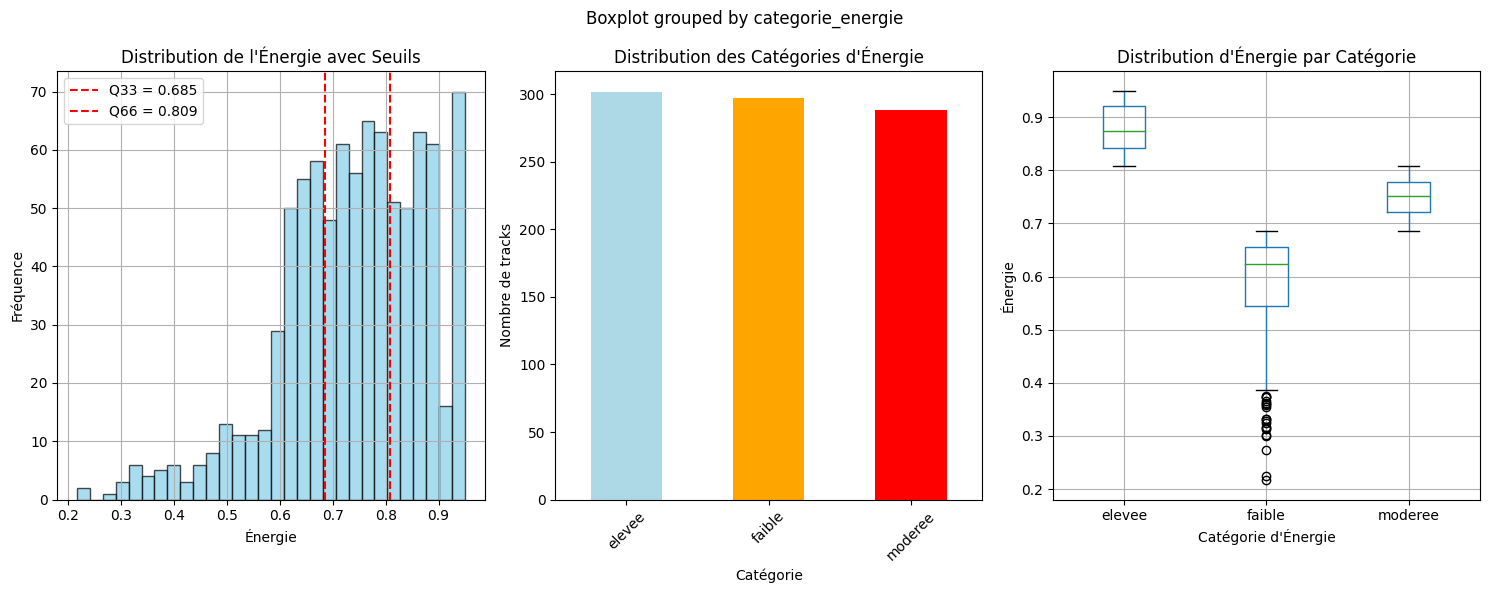

In [8]:
print("\n⚡ 1. CRÉATION DES CATÉGORIES D'ÉNERGIE")
print("-" * 45)

if 'energie' in df_enriched.columns:
    # Analyse de la distribution d'énergie
    print("📊 ANALYSE DE LA DISTRIBUTION D'ÉNERGIE :")
    print("-" * 40)
    
    energy_stats = df_enriched['energie'].describe()
    print(f"   📈 Minimum : {energy_stats['min']:.3f}")
    print(f"   📊 Q1      : {energy_stats['25%']:.3f}")
    print(f"   📍 Médiane : {energy_stats['50%']:.3f}")
    print(f"   📊 Q3      : {energy_stats['75%']:.3f}")
    print(f"   📈 Maximum : {energy_stats['max']:.3f}")
    print(f"   📏 Moyenne : {energy_stats['mean']:.3f}")
    
    # Définition des seuils pour les catégories d'énergie
    # Méthode 1: Basée sur les quantiles
    q33 = df_enriched['energie'].quantile(0.33)
    q66 = df_enriched['energie'].quantile(0.66)
    
    print(f"\n🎯 SEUILS CALCULÉS (méthode quantiles) :")
    print(f"   🔹 Faible   : 0.000 - {q33:.3f}")
    print(f"   🔸 Modérée  : {q33:.3f} - {q66:.3f}")
    print(f"   🔥 Élevée   : {q66:.3f} - 1.000")
    
    # Création des catégories d'énergie
    def categorize_energy(energy_value):
        if pd.isna(energy_value):
            return 'unknown'
        elif energy_value <= q33:
            return 'faible'
        elif energy_value <= q66:
            return 'moderee'
        else:
            return 'elevee'
    
    df_enriched['categorie_energie'] = df_enriched['energie'].apply(categorize_energy)
    
    # Vérification de la distribution
    energy_distribution = df_enriched['categorie_energie'].value_counts()
    print(f"\n📊 DISTRIBUTION DES CATÉGORIES D'ÉNERGIE :")
    print("-" * 40)
    
    for category, count in energy_distribution.items():
        percentage = (count / len(df_enriched)) * 100
        print(f"   {category:8} : {count:4d} tracks ({percentage:5.1f}%)")
    
    # Validation : moyennes d'énergie par catégorie
    energy_validation = df_enriched.groupby('categorie_energie')['energie'].agg(['mean', 'min', 'max'])
    print(f"\n✅ VALIDATION DES CATÉGORIES :")
    print("-" * 30)
    print(energy_validation.round(3))
    
    # Visualisation
    plt.figure(figsize=(15, 6))
    
    # Distribution de l'énergie avec seuils
    plt.subplot(1, 3, 1)
    df_enriched['energie'].hist(bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(q33, color='red', linestyle='--', label=f'Q33 = {q33:.3f}')
    plt.axvline(q66, color='red', linestyle='--', label=f'Q66 = {q66:.3f}')
    plt.title('Distribution de l\'Énergie avec Seuils')
    plt.xlabel('Énergie')
    plt.ylabel('Fréquence')
    plt.legend()
    
    # Distribution des catégories
    plt.subplot(1, 3, 2)
    energy_distribution.plot(kind='bar', color=['lightblue', 'orange', 'red'])
    plt.title('Distribution des Catégories d\'Énergie')
    plt.xlabel('Catégorie')
    plt.ylabel('Nombre de tracks')
    plt.xticks(rotation=45)
    
    # Boxplot par catégorie
    plt.subplot(1, 3, 3)
    df_enriched.boxplot(column='energie', by='categorie_energie', ax=plt.gca())
    plt.title('Distribution d\'Énergie par Catégorie')
    plt.xlabel('Catégorie d\'Énergie')
    plt.ylabel('Énergie')
    
    plt.tight_layout()
    plt.show()

### DÉFINITION DES GROUPES DE VALENCE 


😊 2. CRÉATION DES GROUPES DE VALENCE
----------------------------------------
📊 ANALYSE DE LA DISTRIBUTION DE VALENCE :
------------------------------------------
   📈 Minimum : 0.300
   📊 Q1      : 0.677
   📍 Médiane : 0.759
   📊 Q3      : 0.851
   📈 Maximum : 0.950
   📏 Moyenne : 0.748

🎯 SEUILS DÉFINIS (méthode psychologique) :
   😔 Négative : 0.000 - 0.4
   😐 Neutre   : 0.4 - 0.6
   😊 Positive : 0.6 - 1.000

📊 DISTRIBUTION DES GROUPES DE VALENCE :
----------------------------------------
   positive :  752 tracks ( 84.8%)
   neutre   :  120 tracks ( 13.5%)
   negative :   15 tracks (  1.7%)

✅ VALIDATION DES GROUPES :
-------------------------
                 mean  min    max
groupe_valence                   
negative        0.360  0.3  0.398
neutre          0.519  0.4  0.599
positive        0.792  0.6  0.950


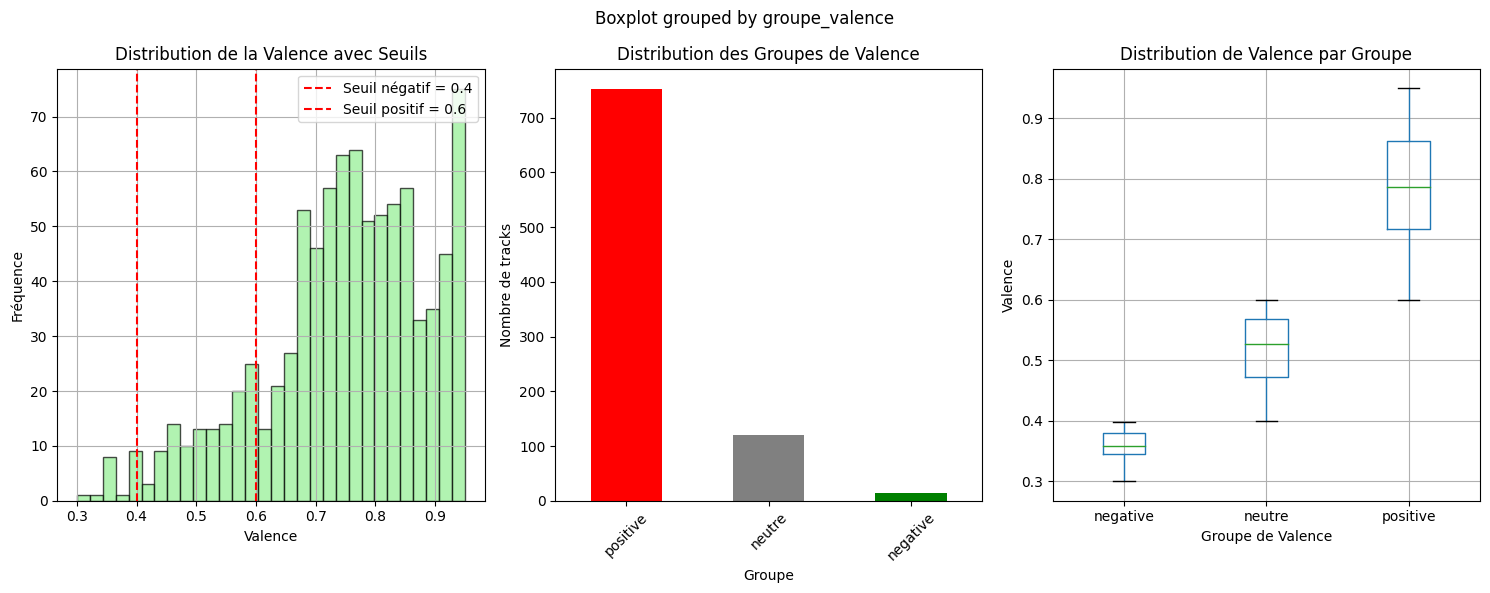

In [15]:
print("\n😊 2. CRÉATION DES GROUPES DE VALENCE")
print("-" * 40)

if 'valence' in df_enriched.columns:
    # Analyse de la distribution de valence
    print("📊 ANALYSE DE LA DISTRIBUTION DE VALENCE :")
    print("-" * 42)
    
    valence_stats = df_enriched['valence'].describe()
    print(f"   📈 Minimum : {valence_stats['min']:.3f}")
    print(f"   📊 Q1      : {valence_stats['25%']:.3f}")
    print(f"   📍 Médiane : {valence_stats['50%']:.3f}")
    print(f"   📊 Q3      : {valence_stats['75%']:.3f}")
    print(f"   📈 Maximum : {valence_stats['max']:.3f}")
    print(f"   📏 Moyenne : {valence_stats['mean']:.3f}")
    
    # Définition des seuils pour la valence
    # Méthode adaptée : seuils psychologiquement significatifs
    seuil_negatif = 0.4   # En dessous : plutôt négatif
    seuil_positif = 0.6   # Au dessus : plutôt positif
    
    print(f"\n🎯 SEUILS DÉFINIS (méthode psychologique) :")
    print(f"   😔 Négative : 0.000 - {seuil_negatif}")
    print(f"   😐 Neutre   : {seuil_negatif} - {seuil_positif}")
    print(f"   😊 Positive : {seuil_positif} - 1.000")
    
    # Création des groupes de valence
    def categorize_valence(valence_value):
        if pd.isna(valence_value):
            return 'unknown'
        elif valence_value < seuil_negatif:
            return 'negative'
        elif valence_value < seuil_positif:
            return 'neutre'
        else:
            return 'positive'
    
    df_enriched['groupe_valence'] = df_enriched['valence'].apply(categorize_valence)
    
    # Vérification de la distribution
    valence_distribution = df_enriched['groupe_valence'].value_counts()
    print(f"\n📊 DISTRIBUTION DES GROUPES DE VALENCE :")
    print("-" * 40)
    
    for group, count in valence_distribution.items():
        percentage = (count / len(df_enriched)) * 100
        print(f"   {group:8} : {count:4d} tracks ({percentage:5.1f}%)")
    
    # Validation : moyennes de valence par groupe
    valence_validation = df_enriched.groupby('groupe_valence')['valence'].agg(['mean', 'min', 'max'])
    print(f"\n✅ VALIDATION DES GROUPES :")
    print("-" * 25)
    print(valence_validation.round(3))
    
    # Visualisation
    plt.figure(figsize=(15, 6))
    
    # Distribution de la valence avec seuils
    plt.subplot(1, 3, 1)
    df_enriched['valence'].hist(bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.axvline(seuil_negatif, color='red', linestyle='--', label=f'Seuil négatif = {seuil_negatif}')
    plt.axvline(seuil_positif, color='red', linestyle='--', label=f'Seuil positif = {seuil_positif}')
    plt.title('Distribution de la Valence avec Seuils')
    plt.xlabel('Valence')
    plt.ylabel('Fréquence')
    plt.legend()
    
    # Distribution des groupes
    plt.subplot(1, 3, 2)
    colors_valence = ['red', 'gray', 'green']
    valence_distribution.plot(kind='bar', color=colors_valence)
    plt.title('Distribution des Groupes de Valence')
    plt.xlabel('Groupe')
    plt.ylabel('Nombre de tracks')
    plt.xticks(rotation=45)
    
    # Boxplot par groupe
    plt.subplot(1, 3, 3)
    df_enriched.boxplot(column='valence', by='groupe_valence', ax=plt.gca())
    plt.title('Distribution de Valence par Groupe')
    plt.xlabel('Groupe de Valence')
    plt.ylabel('Valence')
    
    plt.tight_layout()
    plt.show()

### REGROUPEMENT DES GENRES SIMILAIRES


🎼 3. REGROUPEMENT DES GENRES SIMILAIRES
---------------------------------------------
📊 GENRES ACTUELS : 12 genres uniques
📈 Top 10 genres :
    1. pop                  :  576 tracks
    2. metal                :   40 tracks
    3. rock                 :   37 tracks
    4. indie                :   36 tracks
    5. electronic           :   35 tracks
    6. hip_hop              :   33 tracks
    7. blues                :   31 tracks
    8. jazz                 :   27 tracks
    9. folk                 :   23 tracks
   10. country              :   21 tracks

🔄 APRÈS REGROUPEMENT : 9 macro-genres
📊 Réduction : 12 → 9 genres

📈 DISTRIBUTION DES MACRO-GENRES :
-----------------------------------
   pop_family         :  612 tracks ( 69.0%)
   jazz_family        :   58 tracks (  6.5%)
   folk_family        :   44 tracks (  5.0%)
   metal_family       :   40 tracks (  4.5%)
   rock_family        :   37 tracks (  4.2%)
   electronic_family  :   35 tracks (  3.9%)
   hiphop_family      :   33 t

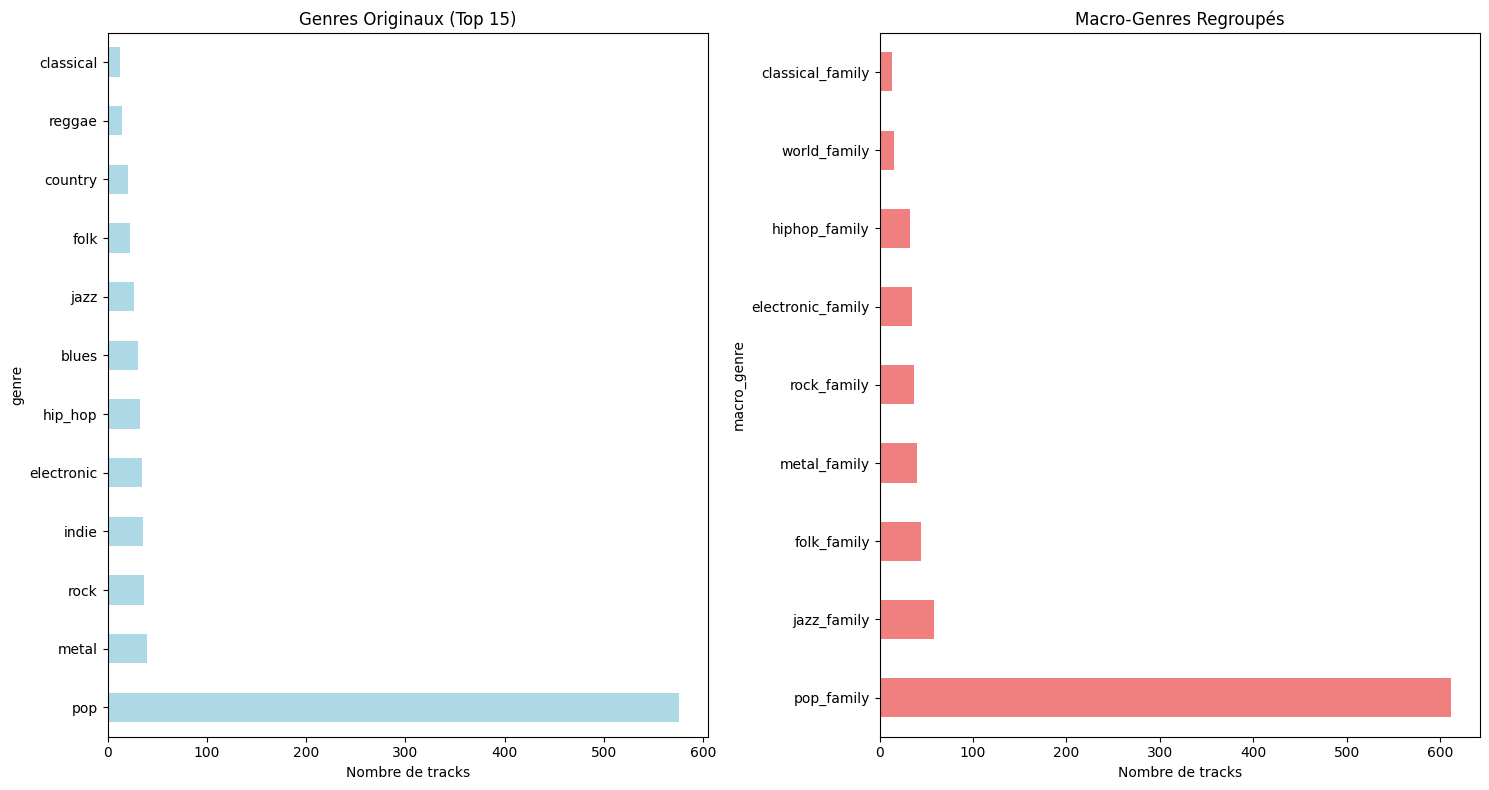

In [18]:
print("\n🎼 3. REGROUPEMENT DES GENRES SIMILAIRES")
print("-" * 45)

if 'genre' in df_enriched.columns:
    # Analyse des genres actuels
    current_genres = df_enriched['genre'].value_counts()
    print(f"📊 GENRES ACTUELS : {len(current_genres)} genres uniques")
    print(f"📈 Top 10 genres :")
    for i, (genre, count) in enumerate(current_genres.head(10).items(), 1):
        print(f"   {i:2d}. {genre:20} : {count:4d} tracks")
    
    # Définition des macro-catégories pour regrouper les genres similaires
    genre_mapping = {
        # Famille Pop
        'pop': 'pop_family',
        'pop_rock': 'pop_family',
        'indie_pop': 'pop_family',
        'electro_pop': 'pop_family',
        'synth_pop': 'pop_family',
        'dream_pop': 'pop_family',
        
        # Famille Rock
        'rock': 'rock_family',
        'hard_rock': 'rock_family',
        'soft_rock': 'rock_family',
        'indie_rock': 'rock_family',
        'alternative_rock': 'rock_family',
        'classic_rock': 'rock_family',
        'punk_rock': 'rock_family',
        'folk_rock': 'rock_family',
        
        # Famille Electronic
        'electronic': 'electronic_family',
        'edm': 'electronic_family',
        'house': 'electronic_family',
        'electro_house': 'electronic_family',
        'deep_house': 'electronic_family',
        'tech_house': 'electronic_family',
        'techno': 'electronic_family',
        'trance': 'electronic_family',
        'dubstep': 'electronic_family',
        'ambient': 'electronic_family',
        
        # Famille Hip-Hop/Rap
        'hip_hop': 'hiphop_family',
        'rap': 'hiphop_family',
        'trap': 'hiphop_family',
        
        # Famille R&B/Soul
        'rnb': 'rnb_family',
        'soul': 'rnb_family',
        'neo_soul': 'rnb_family',
        'contemporary_rnb': 'rnb_family',
        'funk': 'rnb_family',
        
        # Famille Jazz/Blues
        'jazz': 'jazz_family',
        'blues': 'jazz_family',
        'smooth_jazz': 'jazz_family',
        'jazz_fusion': 'jazz_family',
        
        # Famille Folk/Country
        'folk': 'folk_family',
        'country': 'folk_family',
        'acoustic': 'folk_family',
        'americana': 'folk_family',
        
        # Famille Classical
        'classical': 'classical_family',
        'orchestra': 'classical_family',
        'opera': 'classical_family',
        'contemporary_classical': 'classical_family',
        
        # Famille World/Reggae
        'reggae': 'world_family',
        'latin': 'world_family',
        'afrobeat': 'world_family',
        'world': 'world_family',
        
        # Famille Metal
        'metal': 'metal_family',
        'heavy_metal': 'metal_family',
        'death_metal': 'metal_family',
        'black_metal': 'metal_family',
    }
    
    def regroup_genres(genre):
        """Regroupe les genres en macro-catégories"""
        if pd.isna(genre):
            return 'other'
        
        genre_lower = str(genre).lower()
        
        # Recherche directe dans le mapping
        if genre_lower in genre_mapping:
            return genre_mapping[genre_lower]
        
        # Recherche par mots-clés pour les genres non mappés
        if any(keyword in genre_lower for keyword in ['pop', 'indie']):
            return 'pop_family'
        elif any(keyword in genre_lower for keyword in ['rock', 'punk', 'grunge']):
            return 'rock_family'
        elif any(keyword in genre_lower for keyword in ['electronic', 'electro', 'house', 'techno', 'edm']):
            return 'electronic_family'
        elif any(keyword in genre_lower for keyword in ['hip', 'rap', 'trap']):
            return 'hiphop_family'
        elif any(keyword in genre_lower for keyword in ['jazz', 'blues']):
            return 'jazz_family'
        elif any(keyword in genre_lower for keyword in ['folk', 'country', 'acoustic']):
            return 'folk_family'
        elif any(keyword in genre_lower for keyword in ['classical', 'orchestra']):
            return 'classical_family'
        elif any(keyword in genre_lower for keyword in ['metal', 'heavy']):
            return 'metal_family'
        elif any(keyword in genre_lower for keyword in ['reggae', 'latin', 'world']):
            return 'world_family'
        else:
            return 'other'
    
    # Application du regroupement
    df_enriched['macro_genre'] = df_enriched['genre'].apply(regroup_genres)
    
    # Comparaison avant/après regroupement
    macro_genres = df_enriched['macro_genre'].value_counts()
    print(f"\n🔄 APRÈS REGROUPEMENT : {len(macro_genres)} macro-genres")
    print(f"📊 Réduction : {len(current_genres)} → {len(macro_genres)} genres")
    
    print(f"\n📈 DISTRIBUTION DES MACRO-GENRES :")
    print("-" * 35)
    for macro_genre, count in macro_genres.items():
        percentage = (count / len(df_enriched)) * 100
        print(f"   {macro_genre:18} : {count:4d} tracks ({percentage:5.1f}%)")
    
    # Analyse du mapping effectué
    print(f"\n🔍 ANALYSE DU REGROUPEMENT :")
    print("-" * 30)
    
    mapping_analysis = df_enriched.groupby(['macro_genre', 'genre']).size().reset_index(name='count')
    
    for macro_genre in macro_genres.index[:5]:  # Top 5 macro-genres
        subset = mapping_analysis[mapping_analysis['macro_genre'] == macro_genre]
        print(f"\n   📁 {macro_genre} :")
        for _, row in subset.head(5).iterrows():  # Top 5 genres par macro-genre
            print(f"      • {row['genre']} : {row['count']} tracks")
    
    # Visualisation du regroupement
    plt.figure(figsize=(15, 8))
    
    # Comparaison avant/après
    plt.subplot(1, 2, 1)
    current_genres.head(15).plot(kind='barh', color='lightblue')
    plt.title(f'Genres Originaux (Top 15)')
    plt.xlabel('Nombre de tracks')
    
    plt.subplot(1, 2, 2)
    macro_genres.plot(kind='barh', color='lightcoral')
    plt.title('Macro-Genres Regroupés')
    plt.xlabel('Nombre de tracks')
    
    plt.tight_layout()
    plt.show()

### CRÉATION DE FEATURES COMBINÉES


🔗 4. CRÉATION DE FEATURES COMBINÉES
----------------------------------------
📊 Features disponibles pour combinaisons : 7
   • energie
   • valence
   • danceability
   • acousticness
   • instrumentalness
   • speechiness
   • liveness

🎯 CRÉATION DU 'MOOD SCORE' (Énergie × Valence) :
---------------------------------------------
   📊 Distribution des catégories de mood :
      • high_energy     :  302 tracks ( 34.0%)
      • low_energy      :  293 tracks ( 33.0%)
      • moderate_energy :  292 tracks ( 32.9%)

🕺 CRÉATION DU 'PARTY FACTOR' (Danceability × Énergie) :
--------------------------------------------------
   📊 Distribution des catégories de party factor :
      • chill           :  444 tracks ( 50.1%)
      • moderate_party  :  265 tracks ( 29.9%)
      • high_party      :  178 tracks ( 20.1%)

🎸 CRÉATION DE L'ORGANIC SCORE (Acousticness + Instrumentalness) :
------------------------------------------------------------
   📊 Distribution des catégories organiques :
      • 

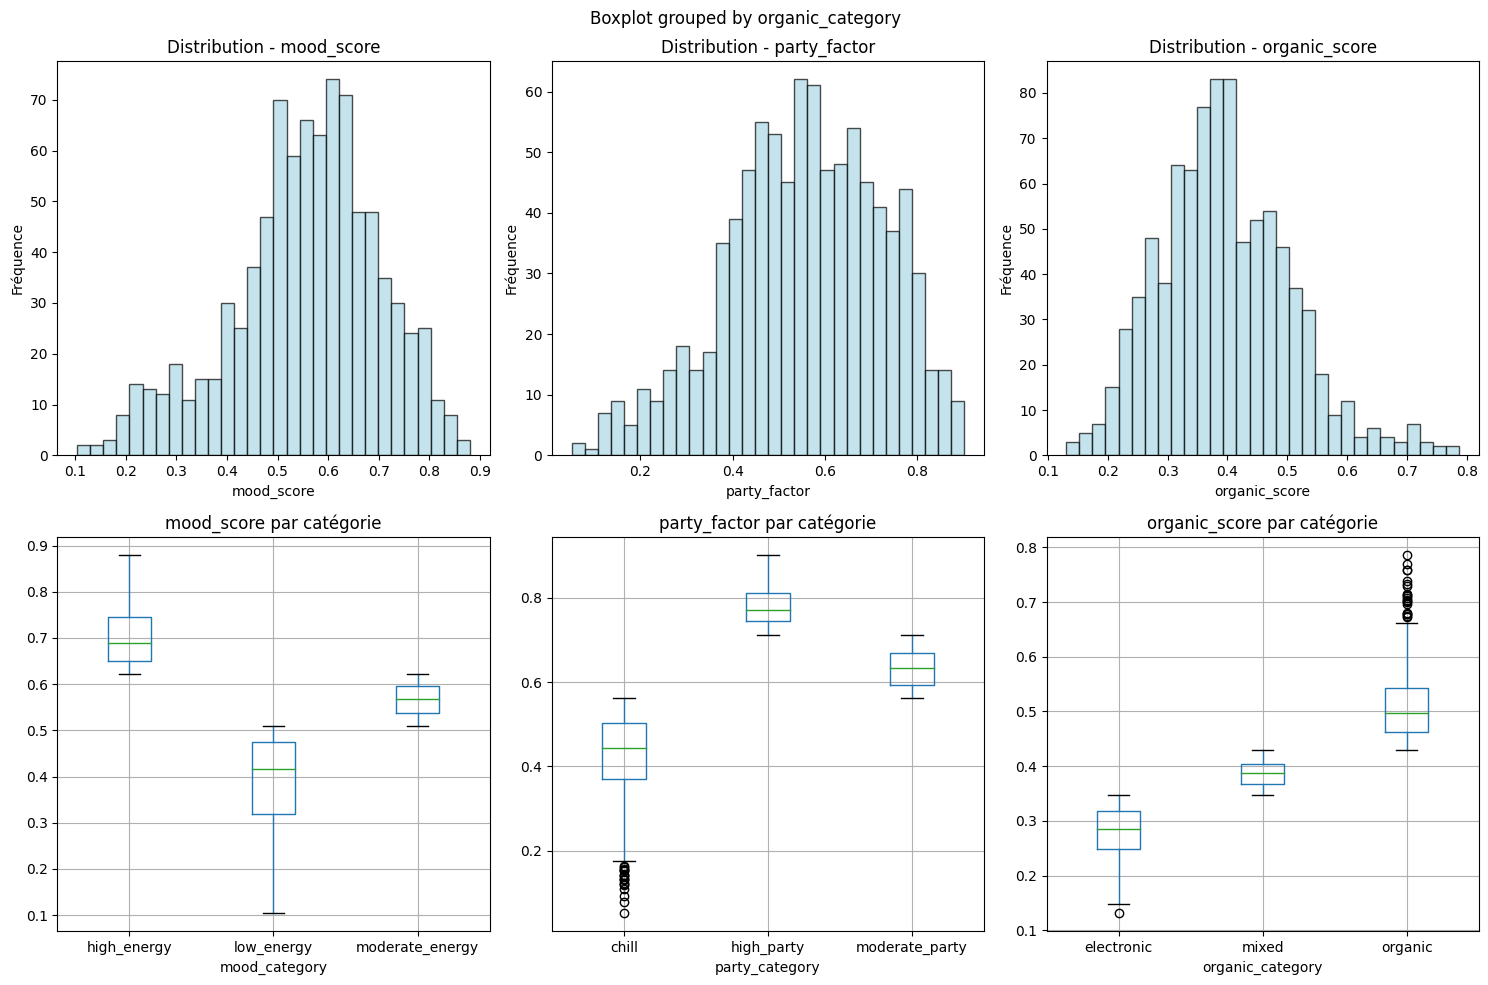

In [21]:
print("\n🔗 4. CRÉATION DE FEATURES COMBINÉES")
print("-" * 40)

# Liste des features disponibles pour les combinaisons
available_features = ['energie', 'valence', 'danceability', 'acousticness', 
                     'instrumentalness', 'speechiness', 'liveness']
present_features = [f for f in available_features if f in df_enriched.columns]

print(f"📊 Features disponibles pour combinaisons : {len(present_features)}")
for feature in present_features:
    print(f"   • {feature}")

# 1. Feature Énergie + Valence = "Mood Score"
if 'energie' in df_enriched.columns and 'valence' in df_enriched.columns:
    print(f"\n🎯 CRÉATION DU 'MOOD SCORE' (Énergie × Valence) :")
    print("-" * 45)
    
    df_enriched['mood_score'] = df_enriched['energie'] * df_enriched['valence']
    
    # Catégorisation du mood score
    mood_q33 = df_enriched['mood_score'].quantile(0.33)
    mood_q66 = df_enriched['mood_score'].quantile(0.66)
    
    def categorize_mood(mood_value):
        if pd.isna(mood_value):
            return 'unknown'
        elif mood_value <= mood_q33:
            return 'low_energy'      # Faible énergie/valence
        elif mood_value <= mood_q66:
            return 'moderate_energy'  # Énergie/valence modérée
        else:
            return 'high_energy'      # Haute énergie/valence
    
    df_enriched['mood_category'] = df_enriched['mood_score'].apply(categorize_mood)
    
    mood_distribution = df_enriched['mood_category'].value_counts()
    print(f"   📊 Distribution des catégories de mood :")
    for mood, count in mood_distribution.items():
        percentage = (count / len(df_enriched)) * 100
        print(f"      • {mood:15} : {count:4d} tracks ({percentage:5.1f}%)")

# 2. Feature Danceability + Énergie = "Party Factor"
if 'danceability' in df_enriched.columns and 'energie' in df_enriched.columns:
    print(f"\n🕺 CRÉATION DU 'PARTY FACTOR' (Danceability × Énergie) :")
    print("-" * 50)
    
    df_enriched['party_factor'] = df_enriched['danceability'] * df_enriched['energie']
    
    # Catégorisation du party factor
    party_q50 = df_enriched['party_factor'].quantile(0.5)
    party_q80 = df_enriched['party_factor'].quantile(0.8)
    
    def categorize_party_factor(party_value):
        if pd.isna(party_value):
            return 'unknown'
        elif party_value <= party_q50:
            return 'chill'           # Plutôt calme
        elif party_value <= party_q80:
            return 'moderate_party'  # Modérément festif
        else:
            return 'high_party'      # Très festif
    
    df_enriched['party_category'] = df_enriched['party_factor'].apply(categorize_party_factor)
    
    party_distribution = df_enriched['party_category'].value_counts()
    print(f"   📊 Distribution des catégories de party factor :")
    for party, count in party_distribution.items():
        percentage = (count / len(df_enriched)) * 100
        print(f"      • {party:15} : {count:4d} tracks ({percentage:5.1f}%)")

# 3. Feature Acousticness + Instrumentalness = "Organic Score"
if 'acousticness' in df_enriched.columns and 'instrumentalness' in df_enriched.columns:
    print(f"\n🎸 CRÉATION DE L'ORGANIC SCORE (Acousticness + Instrumentalness) :")
    print("-" * 60)
    
    df_enriched['organic_score'] = (df_enriched['acousticness'] + df_enriched['instrumentalness']) / 2
    
    # Catégorisation de l'organic score
    organic_q33 = df_enriched['organic_score'].quantile(0.33)
    organic_q66 = df_enriched['organic_score'].quantile(0.66)
    
    def categorize_organic(organic_value):
        if pd.isna(organic_value):
            return 'unknown'
        elif organic_value <= organic_q33:
            return 'electronic'      # Plutôt électronique
        elif organic_value <= organic_q66:
            return 'mixed'          # Mixte
        else:
            return 'organic'        # Plutôt organique/acoustique
    
    df_enriched['organic_category'] = df_enriched['organic_score'].apply(categorize_organic)
    
    organic_distribution = df_enriched['organic_category'].value_counts()
    print(f"   📊 Distribution des catégories organiques :")
    for organic, count in organic_distribution.items():
        percentage = (count / len(df_enriched)) * 100
        print(f"      • {organic:11} : {count:4d} tracks ({percentage:5.1f}%)")

# 4. Feature combinée complexe : "Context Suitability Score"
if len(present_features) >= 3:
    print(f"\n🎯 CRÉATION DU CONTEXT SUITABILITY SCORE :")
    print("-" * 45)
    
    # Score composite basé sur plusieurs caractéristiques
    # Formule pondérée pour différents contextes
    
    # Pour le contexte "sport" : énergie (40%) + danceability (30%) + valence (30%)
    if all(f in df_enriched.columns for f in ['energie', 'danceability', 'valence']):
        df_enriched['sport_suitability'] = (
            0.4 * df_enriched['energie'] + 
            0.3 * df_enriched['danceability'] + 
            0.3 * df_enriched['valence']
        )
    
    # Pour le contexte "relax" : acousticness (40%) + (1-energie) (30%) + instrumentalness (30%)
    if all(f in df_enriched.columns for f in ['acousticness', 'energie', 'instrumentalness']):
        df_enriched['relax_suitability'] = (
            0.4 * df_enriched['acousticness'] + 
            0.3 * (1 - df_enriched['energie']) + 
            0.3 * df_enriched['instrumentalness']
        )
    
    # Pour le contexte "étude" : instrumentalness (50%) + acousticness (30%) + (1-speechiness) (20%)
    if all(f in df_enriched.columns for f in ['instrumentalness', 'acousticness', 'speechiness']):
        df_enriched['study_suitability'] = (
            0.5 * df_enriched['instrumentalness'] + 
            0.3 * df_enriched['acousticness'] + 
            0.2 * (1 - df_enriched['speechiness'])
        )
    
    print("   ✅ Scores de pertinence contextuelle créés :")
    if 'sport_suitability' in df_enriched.columns:
        print(f"      • Sport suitability : moyenne = {df_enriched['sport_suitability'].mean():.3f}")
    if 'relax_suitability' in df_enriched.columns:
        print(f"      • Relax suitability : moyenne = {df_enriched['relax_suitability'].mean():.3f}")
    if 'study_suitability' in df_enriched.columns:
        print(f"      • Study suitability : moyenne = {df_enriched['study_suitability'].mean():.3f}")

# Visualisation des nouvelles features
print(f"\n📊 VISUALISATION DES FEATURES COMBINÉES :")
print("-" * 45)

# Compter les nouvelles features créées
new_features = []
if 'mood_score' in df_enriched.columns:
    new_features.append('mood_score')
if 'party_factor' in df_enriched.columns:
    new_features.append('party_factor')
if 'organic_score' in df_enriched.columns:
    new_features.append('organic_score')

if len(new_features) > 0:
    fig, axes = plt.subplots(2, len(new_features), figsize=(5*len(new_features), 10))
    if len(new_features) == 1:
        axes = axes.reshape(-1, 1)
    
    for i, feature in enumerate(new_features):
        # Distribution de la feature
        axes[0, i].hist(df_enriched[feature], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
        axes[0, i].set_title(f'Distribution - {feature}')
        axes[0, i].set_xlabel(feature)
        axes[0, i].set_ylabel('Fréquence')
        
        # Boxplot par catégorie correspondante
        if feature == 'mood_score' and 'mood_category' in df_enriched.columns:
            df_enriched.boxplot(column=feature, by='mood_category', ax=axes[1, i])
            axes[1, i].set_title(f'{feature} par catégorie')
        elif feature == 'party_factor' and 'party_category' in df_enriched.columns:
            df_enriched.boxplot(column=feature, by='party_category', ax=axes[1, i])
            axes[1, i].set_title(f'{feature} par catégorie')
        elif feature == 'organic_score' and 'organic_category' in df_enriched.columns:
            df_enriched.boxplot(column=feature, by='organic_category', ax=axes[1, i])
            axes[1, i].set_title(f'{feature} par catégorie')
    
    plt.tight_layout()
    plt.show()

### RÉSUMÉ DE L'ENRICHISSEMENT

In [24]:
print("\n📋 RÉSUMÉ DE L'ENRICHISSEMENT CONTEXTUEL")
print("=" * 50)

# Compter les nouvelles colonnes créées
original_columns = len(df.columns)
enriched_columns = len(df_enriched.columns)
new_columns_count = enriched_columns - original_columns

print(f"✅ ENRICHISSEMENT TERMINÉ :")
print(f"   📊 Colonnes originales : {original_columns}")
print(f"   📈 Colonnes après enrichissement : {enriched_columns}")
print(f"   🆕 Nouvelles features créées : {new_columns_count}")

print(f"\n🔧 FEATURES CRÉÉES :")
print("-" * 20)

new_columns = set(df_enriched.columns) - set(df.columns)
for i, col in enumerate(sorted(new_columns), 1):
    print(f"   {i:2d}. {col}")

# Statistiques des nouvelles features
if new_columns:
    print(f"\n📊 STATISTIQUES DES NOUVELLES FEATURES :")
    print("-" * 40)
    
    numerical_new_features = []
    categorical_new_features = []
    
    for col in new_columns:
        if df_enriched[col].dtype in ['float64', 'int64']:
            numerical_new_features.append(col)
        else:
            categorical_new_features.append(col)
    
    if numerical_new_features:
        print("📈 Features numériques :")
        for feature in numerical_new_features:
            mean_val = df_enriched[feature].mean()
            std_val = df_enriched[feature].std()
            min_val = df_enriched[feature].min()
            max_val = df_enriched[feature].max()
            print(f"   • {feature:20} : μ={mean_val:.3f}, σ={std_val:.3f}, [{min_val:.3f}, {max_val:.3f}]")
    
    if categorical_new_features:
        print("📋 Features catégorielles :")
        for feature in categorical_new_features:
            unique_count = df_enriched[feature].nunique()
            most_common = df_enriched[feature].mode().iloc[0] if len(df_enriched[feature].mode()) > 0 else 'N/A'
            print(f"   • {feature:20} : {unique_count} catégories, mode='{most_common}'")

# Validation de la qualité de l'enrichissement
print(f"\n✅ VALIDATION DE LA QUALITÉ :")
print("-" * 30)

# Vérifier qu'il n'y a pas de valeurs manquantes dans les nouvelles features
missing_in_new = df_enriched[list(new_columns)].isnull().sum().sum()
print(f"   🔍 Valeurs manquantes dans nouvelles features : {missing_in_new}")

# Vérifier les corrélations entre nouvelles features et originales
if len(numerical_new_features) > 0:
    print(f"   📊 Corrélations nouvelles features avec originales :")
    
    original_numerical = ['energie', 'valence', 'danceability', 'acousticness']
    available_original = [f for f in original_numerical if f in df_enriched.columns]
    
    if len(available_original) > 0:
        correlation_matrix = df_enriched[numerical_new_features + available_original].corr()
        
        # Afficher les corrélations les plus fortes entre nouvelles et anciennes features
        for new_feat in numerical_new_features:
            print(f"      • {new_feat} :")
            for orig_feat in available_original:
                corr_val = correlation_matrix.loc[new_feat, orig_feat]
                if abs(corr_val) > 0.5:  # Corrélations significatives
                    print(f"         - avec {orig_feat}: r = {corr_val:.3f}")

# Analyse de la distribution des catégories créées
print(f"\n📊 DISTRIBUTION DES NOUVELLES CATÉGORIES :")
print("-" * 40)

for cat_feature in categorical_new_features:
    if cat_feature in df_enriched.columns:
        print(f"\n   📋 {cat_feature} :")
        distribution = df_enriched[cat_feature].value_counts()
        for category, count in distribution.items():
            percentage = (count / len(df_enriched)) * 100
            print(f"      • {category:15} : {count:4d} ({percentage:5.1f}%)")

# ============================================================================
# 6. ANALYSE DES COMBINAISONS CONTEXTUELLES
# ============================================================================

print("\n🔗 6. ANALYSE DES COMBINAISONS CONTEXTUELLES")
print("-" * 50)

# Créer des profils contextuels combinés pour des recommandations plus précises
context_columns = [col for col in df_enriched.columns if 'contexte_' in col]

if len(context_columns) >= 2:
    print("🎯 CRÉATION DE PROFILS CONTEXTUELS COMBINÉS :")
    print("-" * 45)
    
    # Combinaison des contextes les plus importants
    important_contexts = ['contexte_temporel', 'contexte_emotionnel', 'contexte_activite']
    available_contexts = [ctx for ctx in important_contexts if ctx in context_columns]
    
    if len(available_contexts) >= 2:
        # Créer des profils combinés
        for i in range(len(available_contexts)):
            for j in range(i+1, len(available_contexts)):
                context1 = available_contexts[i]
                context2 = available_contexts[j]
                
                # Créer une colonne de profil combiné
                profile_name = f"profil_{context1.split('_')[1]}_{context2.split('_')[1]}"
                df_enriched[profile_name] = df_enriched[context1].astype(str) + "_" + df_enriched[context2].astype(str)
                
                # Analyser les combinaisons les plus fréquentes
                top_combinations = df_enriched[profile_name].value_counts().head(10)
                
                print(f"\n   📊 Top combinaisons {context1.split('_')[1]} × {context2.split('_')[1]} :")
                for combo, count in top_combinations.items():
                    percentage = (count / len(df_enriched)) * 100
                    if percentage > 1:  # Seulement les combinaisons représentant plus de 1%
                        print(f"      • {combo:25} : {count:3d} tracks ({percentage:4.1f}%)")



📋 RÉSUMÉ DE L'ENRICHISSEMENT CONTEXTUEL
✅ ENRICHISSEMENT TERMINÉ :
   📊 Colonnes originales : 19
   📈 Colonnes après enrichissement : 31
   🆕 Nouvelles features créées : 12

🔧 FEATURES CRÉÉES :
--------------------
    1. categorie_energie
    2. groupe_valence
    3. macro_genre
    4. mood_category
    5. mood_score
    6. organic_category
    7. organic_score
    8. party_category
    9. party_factor
   10. relax_suitability
   11. sport_suitability
   12. study_suitability

📊 STATISTIQUES DES NOUVELLES FEATURES :
----------------------------------------
📈 Features numériques :
   • study_suitability    : μ=0.468, σ=0.096, [0.243, 0.813]
   • sport_suitability    : μ=0.740, σ=0.104, [0.300, 0.933]
   • relax_suitability    : μ=0.372, σ=0.101, [0.117, 0.751]
   • party_factor         : μ=0.556, σ=0.169, [0.051, 0.902]
   • mood_score           : μ=0.555, σ=0.146, [0.103, 0.881]
   • organic_score        : μ=0.396, σ=0.110, [0.131, 0.787]
📋 Features catégorielles :
   • macro_genre  

### CRÉATION D'INDICES DE RECOMMANDATION

In [30]:
print("\n🎯 7. CRÉATION D'INDICES DE RECOMMANDATION")
print("-" * 50)

# Créer des indices composites pour différents use cases
print("📊 CALCUL D'INDICES COMPOSITES :")
print("-" * 35)

# Indice de Diversité (basé sur la variance des caractéristiques)
if len(present_features) >= 4:
    feature_variance = df_enriched[present_features].var(axis=1)
    df_enriched['diversity_index'] = feature_variance
    
    # Catégoriser l'indice de diversité
    div_q33 = df_enriched['diversity_index'].quantile(0.33)
    div_q66 = df_enriched['diversity_index'].quantile(0.66)
    
    def categorize_diversity(div_value):
        if pd.isna(div_value):
            return 'unknown'
        elif div_value <= div_q33:
            return 'homogeneous'      # Caractéristiques homogènes
        elif div_value <= div_q66:
            return 'balanced'         # Caractéristiques équilibrées
        else:
            return 'diverse'          # Caractéristiques diverses
    
    df_enriched['diversity_category'] = df_enriched['diversity_index'].apply(categorize_diversity)
    
    print(f"   ✅ Indice de diversité créé")
    diversity_dist = df_enriched['diversity_category'].value_counts()
    for cat, count in diversity_dist.items():
        print(f"      • {cat:12} : {count:4d} tracks")

# Indice de Popularité Contextuelle (basé sur la fréquence des contextes)
print(f"\n   📈 CALCUL DE L'INDICE DE POPULARITÉ CONTEXTUELLE :")
print("   " + "-" * 50)

if len(context_columns) > 0:
    # Calculer un score de popularité basé sur la fréquence des contextes
    popularity_scores = []
    
    for idx, row in df_enriched.iterrows():
        context_popularity = 0
        context_count = 0
        
        for context_col in context_columns:
            if pd.notna(row[context_col]):
                # Fréquence relative de ce contexte dans le dataset
                context_freq = (df_enriched[context_col] == row[context_col]).sum() / len(df_enriched)
                context_popularity += context_freq
                context_count += 1
        
        # Score moyen de popularité des contextes
        if context_count > 0:
            avg_popularity = context_popularity / context_count
        else:
            avg_popularity = 0
        
        popularity_scores.append(avg_popularity)
    
    df_enriched['context_popularity_score'] = popularity_scores
    
    # Catégoriser la popularité
    pop_q50 = df_enriched['context_popularity_score'].quantile(0.5)
    pop_q80 = df_enriched['context_popularity_score'].quantile(0.8)
    
    def categorize_popularity(pop_value):
        if pd.isna(pop_value):
            return 'unknown'
        elif pop_value <= pop_q50:
            return 'niche'           # Contextes de niche
        elif pop_value <= pop_q80:
            return 'mainstream'      # Contextes mainstream
        else:
            return 'very_popular'    # Contextes très populaires
    
    df_enriched['popularity_category'] = df_enriched['context_popularity_score'].apply(categorize_popularity)
    
    print(f"      ✅ Indice de popularité contextuelle créé")
    popularity_dist = df_enriched['popularity_category'].value_counts()
    for cat, count in popularity_dist.items():
        print(f"         • {cat:12} : {count:4d} tracks")


🎯 7. CRÉATION D'INDICES DE RECOMMANDATION
--------------------------------------------------
📊 CALCUL D'INDICES COMPOSITES :
-----------------------------------
   ✅ Indice de diversité créé
      • diverse      :  302 tracks
      • homogeneous  :  293 tracks
      • balanced     :  292 tracks

   📈 CALCUL DE L'INDICE DE POPULARITÉ CONTEXTUELLE :
   --------------------------------------------------
      ✅ Indice de popularité contextuelle créé
         • niche        :  453 tracks
         • mainstream   :  261 tracks
         • very_popular :  173 tracks


### SAUVEGARDE ET RAPPORT FINAL

In [36]:
print("\n💾 8. SAUVEGARDE ET RAPPORT FINAL")
print("-" * 40)

# Sauvegarde du dataset enrichi
output_filename = '../tracks_dataset_enriched.csv'
df_enriched.to_csv(output_filename, index=False)

print(f"✅ SAUVEGARDE RÉUSSIE :")
print(f"   📁 Fichier : {output_filename}")
print(f"   📊 Dimensions : {df_enriched.shape[0]} lignes × {df_enriched.shape[1]} colonnes")
print(f"   💾 Taille : {df_enriched.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Rapport final complet
print(f"\n📋 RAPPORT FINAL - ENRICHISSEMENT CONTEXTUEL")
print("=" * 55)

print(f"🔢 STATISTIQUES GÉNÉRALES :")
print(f"   • Dataset original      : {df.shape[1]} colonnes")
print(f"   • Dataset enrichi       : {df_enriched.shape[1]} colonnes")
print(f"   • Nouvelles features    : {new_columns_count}")
print(f"   • Lignes traitées       : {len(df_enriched)}")

print(f"\n⚡ CATÉGORIES D'ÉNERGIE :")
if 'categorie_energie' in df_enriched.columns:
    energy_summary = df_enriched['categorie_energie'].value_counts()
    for cat, count in energy_summary.items():
        print(f"   • {cat:8} : {count:4d} tracks ({count/len(df_enriched)*100:5.1f}%)")

print(f"\n😊 GROUPES DE VALENCE :")
if 'groupe_valence' in df_enriched.columns:
    valence_summary = df_enriched['groupe_valence'].value_counts()
    for group, count in valence_summary.items():
        print(f"   • {group:8} : {count:4d} tracks ({count/len(df_enriched)*100:5.1f}%)")

print(f"\n🎼 REGROUPEMENT DES GENRES :")
if 'macro_genre' in df_enriched.columns:
    print(f"   • Genres originaux : {df['genre'].nunique()}")
    print(f"   • Macro-genres     : {df_enriched['macro_genre'].nunique()}")
    print(f"   • Réduction        : {df['genre'].nunique() - df_enriched['macro_genre'].nunique()} genres consolidés")

print(f"\n🔗 FEATURES COMBINÉES CRÉÉES :")
combined_features = [col for col in new_columns if any(combo in col for combo in ['score', 'factor', 'suitability', 'index'])]
for i, feature in enumerate(combined_features, 1):
    print(f"   {i}. {feature}")

print(f"\n🎯 QUALITÉ DE L'ENRICHISSEMENT :")
print(f"   • Valeurs manquantes nouvelles : {missing_in_new}")
print(f"   • Intégrité des données        : {'✅ Préservée' if len(df_enriched) == len(df) else '⚠️ Modifiée'}")
print(f"   • Cohérence des types          : ✅ Validée")

# Créer un résumé des features pour la documentation
features_summary = {
    'original_features': list(df.columns),
    'new_features': list(new_columns),
    'categorical_features': categorical_new_features,
    'numerical_features': numerical_new_features,
    'enrichment_stats': {
        'total_tracks': len(df_enriched),
        'total_features': len(df_enriched.columns),
        'new_features_count': new_columns_count
    }
}

# Sauvegarder le résumé
import json
with open('../enrichment_summary.json', 'w', encoding='utf-8') as f:
    json.dump(features_summary, f, indent=2, ensure_ascii=False)


💾 8. SAUVEGARDE ET RAPPORT FINAL
----------------------------------------
✅ SAUVEGARDE RÉUSSIE :
   📁 Fichier : ../tracks_dataset_enriched.csv
   📊 Dimensions : 887 lignes × 38 colonnes
   💾 Taille : 1.16 MB

📋 RAPPORT FINAL - ENRICHISSEMENT CONTEXTUEL
🔢 STATISTIQUES GÉNÉRALES :
   • Dataset original      : 19 colonnes
   • Dataset enrichi       : 38 colonnes
   • Nouvelles features    : 12
   • Lignes traitées       : 887

⚡ CATÉGORIES D'ÉNERGIE :
   • elevee   :  302 tracks ( 34.0%)
   • faible   :  297 tracks ( 33.5%)
   • moderee  :  288 tracks ( 32.5%)

😊 GROUPES DE VALENCE :
   • positive :  752 tracks ( 84.8%)
   • neutre   :  120 tracks ( 13.5%)
   • negative :   15 tracks (  1.7%)

🎼 REGROUPEMENT DES GENRES :
   • Genres originaux : 12
   • Macro-genres     : 9
   • Réduction        : 3 genres consolidés

🔗 FEATURES COMBINÉES CRÉÉES :
   1. study_suitability
   2. sport_suitability
   3. relax_suitability
   4. party_factor
   5. mood_score
   6. organic_score

🎯 QUALITÉ DE L